In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error, precision_score, recall_score, f1_score, accuracy_score
from scipy.stats import norm
import wfdb
import pandas as pd
import time
import random
import json  # for storing arrays as strings
from scipy.stats import fisher_exact, mannwhitneyu
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# ============ REPRODUCIBLITY BLOCK ==============
seed = 42
random.seed(seed)
np.random.seed(seed)

# ====== LOAD REAL ECG ======
record = '106'
fs = 360  # Sampling frequency in Hz
data_folder = 'mitdb_data_full'
annotation_folder = 'mit-bih-arrhythmia-database-1.0.0'

NORMAL_BEATS = ['.', 'N', 'L', 'R', 'e', 'j']
ARRHYTHMIC_BEATS = ['A', 'a', 'J', 'S', 'V', 'E', 'F']

# ====== Load annotations ======
record_path = os.path.join(annotation_folder, record)
ann = wfdb.rdann(record_path, extension='atr')

# ====== Load signal ======
signal_path = os.path.join(data_folder, f'{record}.npy')
signal = np.load(signal_path)[:, 0]  # Lead I only

# ====== Parameters ======
beat_length = 180  # samples before the beat

# ====== FUNCTION: Extract beat segments ======
def get_segments(signal, ann_samples, ann_symbols, beat_length, target_symbols):
    segments = []
    indices = []
    for s, sym in zip(ann_samples, ann_symbols):
        if sym in target_symbols and s >= beat_length:
            seg = signal[s - beat_length:s]
            segments.append(seg)
            indices.append(s)
    return segments, indices

# ====== Extract normal and arrhythmic beats ======
normal_segments, normal_indices = get_segments(signal, ann.sample, ann.symbol, beat_length, NORMAL_BEATS)
arr_segments, arr_indices = get_segments(signal, ann.sample, ann.symbol, beat_length, ARRHYTHMIC_BEATS)

# ---- Basic numbers ----
num_total_norm = len(normal_segments)
num_train_beats = 500
num_val_beats = 100

num_test_norm = 100
num_test_arr = 100

# ---- Random split for normal beats ----
all_norm_indices = np.arange(num_total_norm)

# Shuffle the indices to randomize selection
np.random.shuffle(all_norm_indices)

# Choose random validation indices *within* normal beats
val_indices = all_norm_indices[:num_val_beats]
train_indices = all_norm_indices[num_val_beats:num_val_beats + num_train_beats]
test_norm_indices = all_norm_indices[num_val_beats + num_train_beats:
                                     num_val_beats + num_train_beats + num_test_norm]

# ---- Create splits ----
train_segments = [normal_segments[i] for i in train_indices]
val_segments = [normal_segments[i] for i in val_indices]
test_segments = [normal_segments[i] for i in test_norm_indices] + arr_segments[:num_test_arr]

# ====== Create test labels ======
# Normal beats → 0, Arrhythmic beats → 1
test_labels = [0]*len(test_norm_indices) + [1]*num_test_arr
test_labels = np.array(test_labels)

print(f"Train: {len(train_segments)} normal beats")
print(f"Validation: {len(val_segments)} normal beats")
print(f"Test: {len(test_segments)} beats ({len(test_norm_indices)} normal + {num_test_arr} arrhythmic)")

# ====== Convert to numpy arrays ======
train_segments = np.array(train_segments)
val_segments = np.array(val_segments)
test_segments = np.array(test_segments)

print(f"\nShapes:")
print(f"  Train: {train_segments.shape}")
print(f"  Validation: {val_segments.shape}")
print(f"  Test: {test_segments.shape}")

# ====== BEAT-BASED DATA PREP (no continuous time) ======
def sliding_data(segment, input_len):
    """
    Generate input-output pairs (X, Y) for one 1D segment.
    Returns:
        X_y : (input_len x num_windows)
    """
    X_y = []
    for t_idx in range(len(segment) - input_len + 1):
        X_y.append(segment[t_idx : t_idx + input_len])
    return np.array(X_y).T



Train: 500 normal beats
Validation: 100 normal beats
Test: 200 beats (100 normal + 100 arrhythmic)

Shapes:
  Train: (500, 180)
  Validation: (100, 180)
  Test: (200, 180)



Running PCA for input_len = 10
Train shape: (85500, 10), Test shape: (34200, 10)


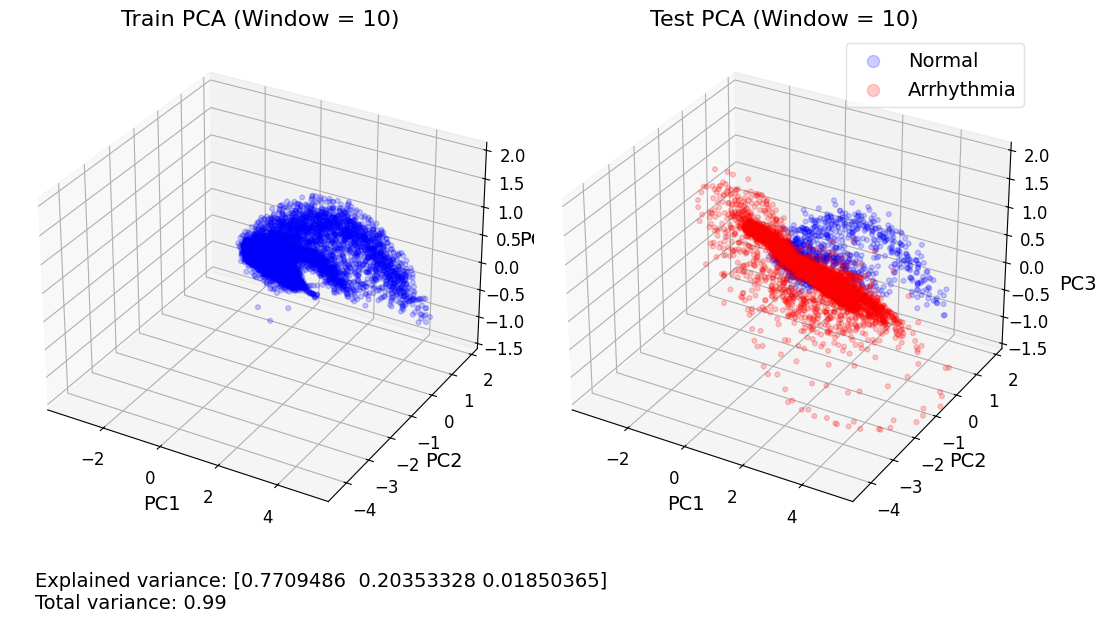


Running PCA for input_len = 20
Train shape: (80500, 20), Test shape: (32200, 20)


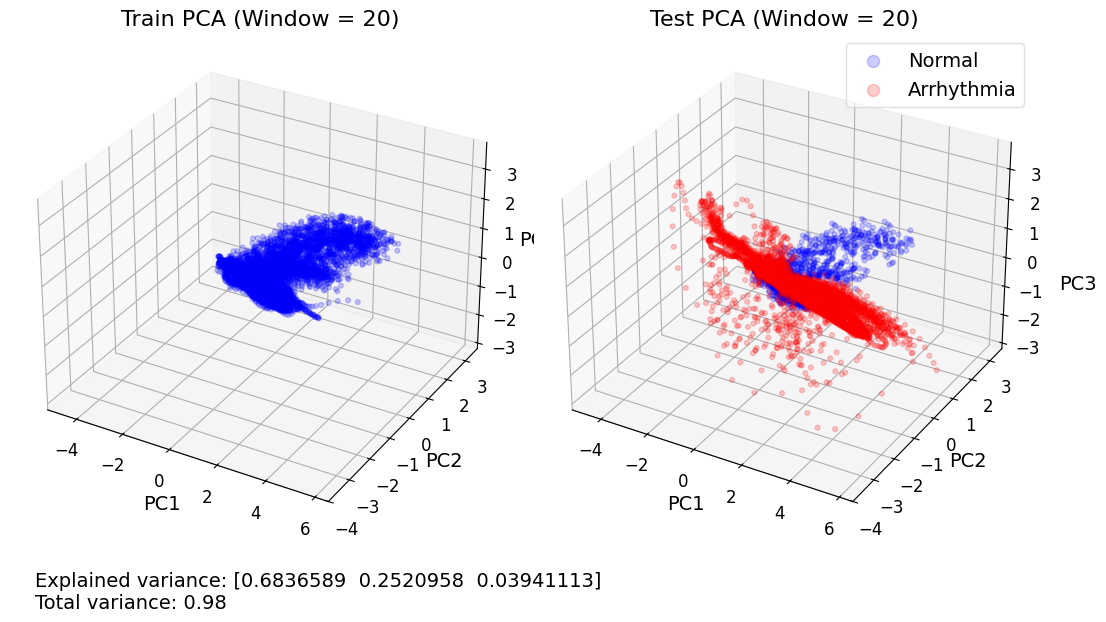


Running PCA for input_len = 30
Train shape: (75500, 30), Test shape: (30200, 30)


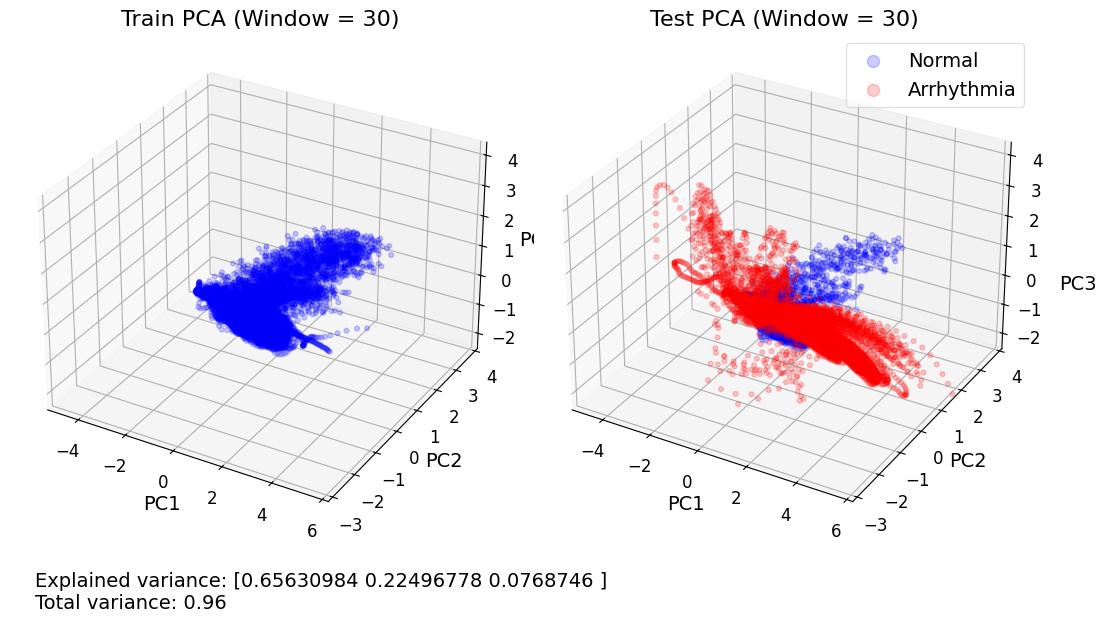


Running PCA for input_len = 40
Train shape: (70500, 40), Test shape: (28200, 40)


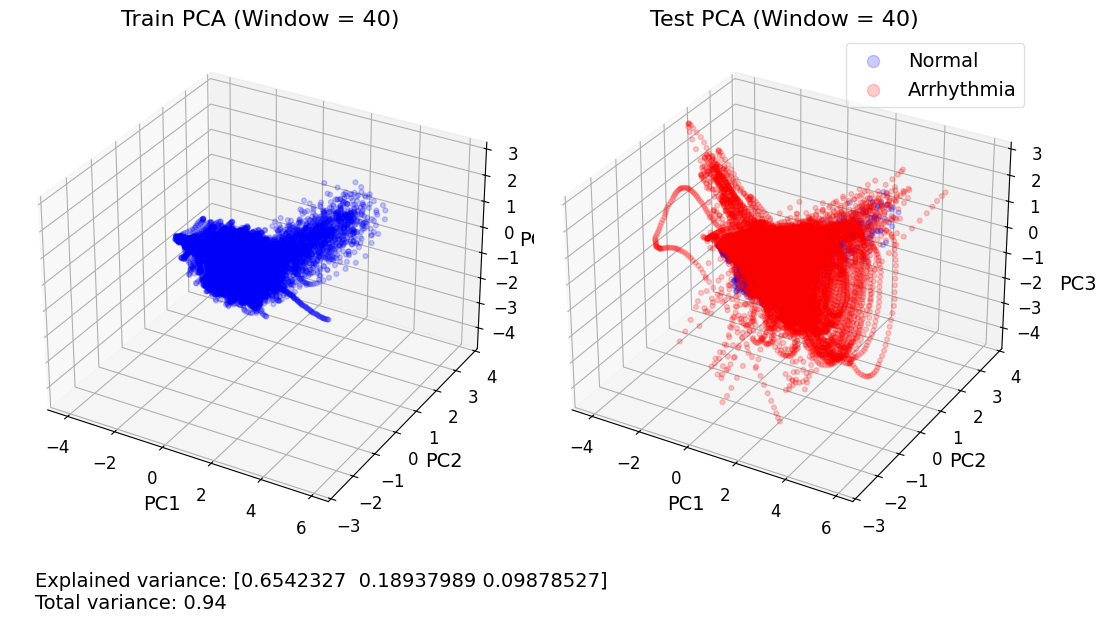


Running PCA for input_len = 50
Train shape: (65500, 50), Test shape: (26200, 50)


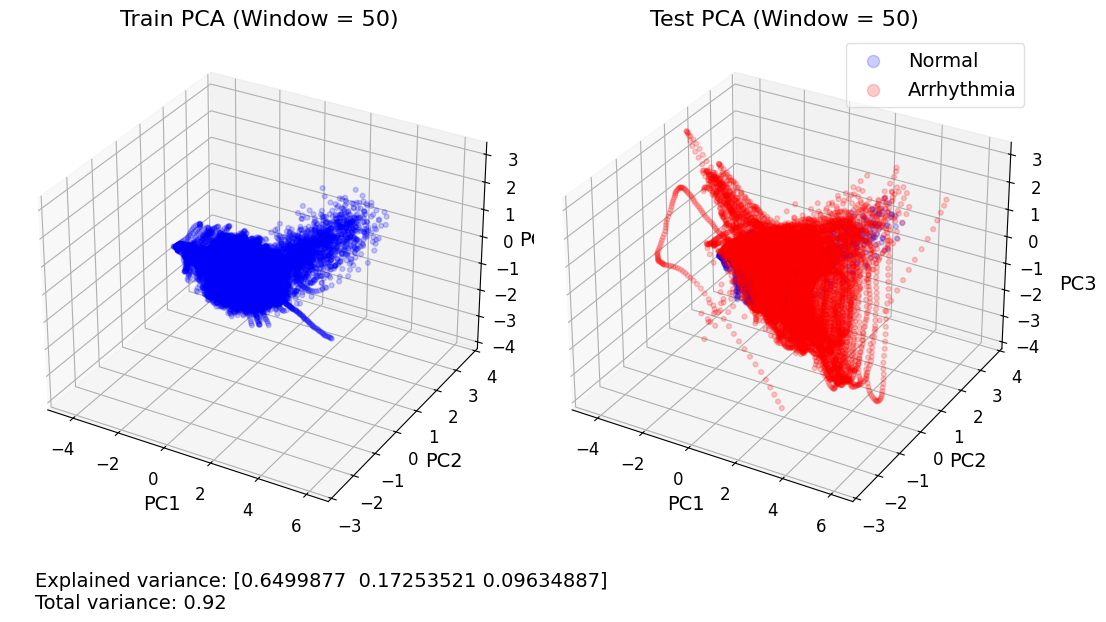

In [6]:
# ================================
# LOOP OVER MULTIPLE INPUT LENGTHS - 3D PCA WITH LARGER TEXT
# ================================
for input_len in [10, 20, 30, 40, 50]:
    print("\n" + "="*80)
    print(f"Running PCA for input_len = {input_len}")
    print("="*80)

    # --------------------------------------------------
    # 1. Build RAW TRAIN WINDOWS
    # --------------------------------------------------
    all_X_y_raw = []
    for seg in train_segments:
        if len(seg) < input_len:
            continue
        X_y_raw = sliding_data(seg, input_len)
        if X_y_raw.size == 0:
            continue
        all_X_y_raw.append(X_y_raw)

    X_train = np.hstack(all_X_y_raw).T

    # --------------------------------------------------
    # 2. Build RAW TEST WINDOWS AND LABELS
    # --------------------------------------------------
    all_X_y_test_raw = []
    all_test_labels = []

    for seg, label in zip(test_segments, test_labels):
        if len(seg) < input_len:
            continue
        X_y_test_raw = sliding_data(seg, input_len)
        if X_y_test_raw.size == 0:
            continue
        all_X_y_test_raw.append(X_y_test_raw)
        all_test_labels.extend([label] * X_y_test_raw.shape[1])

    X_test = np.hstack(all_X_y_test_raw).T
    all_test_labels = np.array(all_test_labels)

    print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

    # --------------------------------------------------
    # 3. PCA TRAIN (3 comps)
    # --------------------------------------------------
    pca_train = PCA(n_components=3)
    train_pca = pca_train.fit_transform(X_train)

    train_expl = pca_train.explained_variance_ratio_
    train_total = train_expl.sum()

    # --------------------------------------------------
    # 4. PROJECT TEST ON TRAIN PCA
    # --------------------------------------------------
    test_pca = pca_train.transform(X_test)  # use train PCA to project test

    # --------------------------------------------------
    # 5. FIX AXES LIMITS
    # --------------------------------------------------
    x_min = min(train_pca[:,0].min(), test_pca[:,0].min())
    x_max = max(train_pca[:,0].max(), test_pca[:,0].max())
    
    y_min = min(train_pca[:,1].min(), test_pca[:,1].min())
    y_max = max(train_pca[:,1].max(), test_pca[:,1].max())
    
    z_min = min(train_pca[:,2].min(), test_pca[:,2].min())
    z_max = max(train_pca[:,2].max(), test_pca[:,2].max())

    # --------------------------------------------------
    # 6. SIDE-BY-SIDE PLOTS
    # --------------------------------------------------
    fig = plt.figure(figsize=(16,6))

    # ----- TRAIN -----
    ax1 = fig.add_subplot(1,2,1, projection='3d')
    ax1.scatter(train_pca[:,0], train_pca[:,1], train_pca[:,2],
                c='blue', s=12, alpha=0.2)  # slightly bigger markers
    ax1.set_xlim(x_min, x_max)
    ax1.set_ylim(y_min, y_max)
    ax1.set_zlim(z_min, z_max)
    ax1.set_title(f"Train PCA (Window = {input_len})", fontsize=16)
    ax1.set_xlabel("PC1", fontsize=14)
    ax1.set_ylabel("PC2", fontsize=14)
    ax1.set_zlabel("PC3", fontsize=14)
    ax1.tick_params(axis='both', labelsize=12)
    ax1.text2D(0.05, -0.15,
               f"Explained variance: {train_expl}\nTotal variance: {train_total:.2f}",
               transform=ax1.transAxes,
               fontsize=14)

    # ----- TEST -----
    ax2 = fig.add_subplot(1,2,2, projection='3d')
    ax2.scatter(test_pca[all_test_labels==0,0], 
                test_pca[all_test_labels==0,1], 
                test_pca[all_test_labels==0,2],
                c='blue', s=12, alpha=0.2, label='Normal')  # bigger markers
    ax2.scatter(test_pca[all_test_labels==1,0], 
                test_pca[all_test_labels==1,1], 
                test_pca[all_test_labels==1,2],
                c='red', s=12, alpha=0.2, label='Arrhythmia')

    ax2.set_xlim(x_min, x_max)
    ax2.set_ylim(y_min, y_max)
    ax2.set_zlim(z_min, z_max)
    ax2.set_title(f"Test PCA (Window = {input_len})", fontsize=16)
    ax2.set_xlabel("PC1", fontsize=14)
    ax2.set_ylabel("PC2", fontsize=14)
    ax2.set_zlabel("")  # disable default
    ax2.tick_params(axis='both', labelsize=12)
    # PC3 label outside the 3D plot
    ax2.text2D(
        1.05, 0.5, "PC3", 
        transform=ax2.transAxes,
        rotation=0,
        va="center",
        ha="left",
        fontsize=14
    )
    ax2.legend(
        markerscale=2.5,
        fontsize=14,
        frameon=True,
        framealpha=0.6   # <-- controls legend box transparency
    )

    # --------------------------------------------------
    # 7. SAVE HIGH-RES FIGURE
    # --------------------------------------------------
    save_dir = f"PCA_patient{record}"
    os.makedirs(save_dir, exist_ok=True)

    fig_name = f"PCA_patient{record}_window_{input_len}.png"
    fig_path = os.path.join(save_dir, fig_name)

    fig.savefig(
        fig_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.subplots_adjust(
        left=0.10,
        right=0.74,   # keeps space for PC3 label
        bottom=0.08,
        top=0.92,
        wspace=0.05
    )
    plt.show()
